In [ ]:
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt



Convergencia alcanzada
Iteraciones: 2220
Error: 0.0009973863689189955


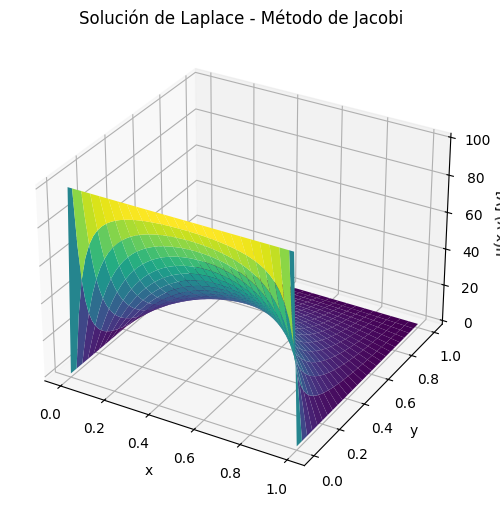

In [ ]:
L = 1.0
N = 51                  # número de puntos en cada dirección
tol = 1e-3              # tolerancia
max_iter = 100000

h = L / (N - 1)

# ============================================================
# Malla
# ============================================================

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)

# Matriz del potencial
u = np.zeros((N, N))

# ============================================================
# Condiciones de frontera
# ============================================================

# u(x,0) = 100 V
u[0, :] = 100.0

# u(0,y) = 0
u[:, 0] = 0.0

# u(L,y) = 0
u[:, -1] = 0.0

# u(x,L) = 0
u[-1, :] = 0.0

for iteration in range(max_iter):

    u_new = u.copy()

    # Puntos interiores
    u_new[1:-1, 1:-1] = 0.25 * (
        u[:-2, 1:-1] +
        u[2:, 1:-1] +
        u[1:-1, :-2] +
        u[1:-1, 2:]
    )


    error = np.max(np.abs(u_new - u))

    u = u_new

    if error < tol:
        print("Convergencia alcanzada")
        print("Iteraciones:", iteration + 1)
        print("Error:", error)
        break

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, u, cmap='viridis')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x,y) [V]")
ax.set_title("Solución de Laplace - Método de Jacobi")

plt.show()


La estrategia consistió en discretizar el dominio cuadrado en una malla bidimensional aplicando condiciones de frontera de Dirichlet (un lado a 100V y el resto a 0V), partiendo de una estimación inicial nula en el interior.

El algoritmo implementa el método de Jacobi, donde en cada iteración se actualiza el potencial de cada punto interno como el promedio aritmético de sus cuatro vecinos adyacentes mediante el esquema de diferencias finitas. Este proceso se repite hasta que la diferencia máxima absoluta entre una iteración y la anterior es inferior a la tolerancia de 10^-3.


Convergencia de la serie alcanzada con 50 términos.
Diferencia máxima final: 8.526513e-14


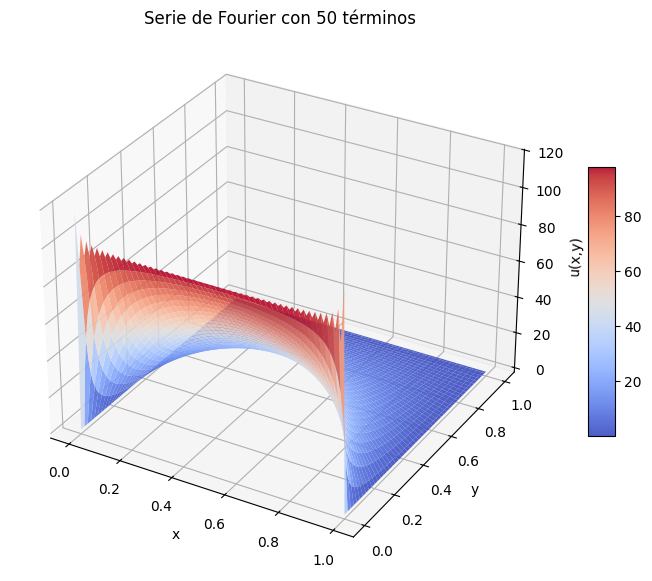

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del problema
L = 1.0
V0 = 100.0
N_max = 500            # Máximo de términos a probar
tol = 1e-4             # Tolerancia solicitada

# Malla para la visualización de la serie (100x100 para que se vea suave)
x_f = np.linspace(0, L, 100)
y_f = np.linspace(0, L, 100)
X, Y = np.meshgrid(x_f, y_f)

# Función que calcula el término 'n' de la serie de Fourier
def un(x, y, n, L, V0):
    # n debe ser impar (1, 3, 5...)
    # Solución analítica para u(x,0)=V0, demás fronteras = 0
    coef = (4 * V0) / (n * np.pi * np.sinh(n * np.pi))
    term = coef * np.sin(n * np.pi * x / L) * np.sinh(n * np.pi * (L - y) / L)
    return term

# Inicialización
z = np.zeros((100, 100))
z_old = np.zeros((100, 100))
n = 1
term_count = 0

# Bucle de suma de la serie
while n <= N_max:
    z += un(X, Y, n, L, V0)
    term_count += 1

    # Comprobar la diferencia máxima entre esta iteración y la anterior
    if term_count > 1: # Empezar a comparar después del primer término
        error = np.max(np.abs(z - z_old))
        if error < tol:
            print(f"Convergencia de la serie alcanzada con {term_count} términos.")
            print(f"Diferencia máxima final: {error:.6e}")
            break

    z_old = z.copy()
    n += 2  # Solo términos impares

# Graficar
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection='3d')
surf = ax.plot_surface(X, Y, z, cmap='coolwarm', alpha=0.9, edgecolor='none')

ax.set_title(f'Serie de Fourier con {term_count} términos')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y)')
fig.colorbar(surf, shrink=0.5, aspect=10)

plt.show()

#EJERCICIO 2 (bonus) No se califica



Solución de la ecuación de Laplace

Consideremos la ecuación de Laplace en dos dimensiones:

$$
\frac{\partial^2 u}{\partial x^2}
+
\frac{\partial^2 u}{\partial y^2}
=0
$$

en la región

$$
0<x<L,\qquad y>0.
$$

Las condiciones de frontera son:

$$
u(x,0)=u_0\sin\left(\frac{2\pi x}{L}\right),
$$

$$
u(0,y)=0,
$$

$$
u(L,y)=0,
$$

$$
u(x,\infty)=0.
$$

Separación de variables

Suponemos una solución de la forma

$$
u(x,y)=X(x)Y(y).
$$

Mediante separación de variables se obtiene

$$
\frac{X''}{X}=-k^2,
$$

y

$$
\frac{Y''}{Y}=k^2.
$$

Las soluciones de estas ecuaciones son

$$
X(x)=A\cos(kx)+B\sin(kx),
$$

y

$$
Y(y)=Ce^{ky}+De^{-ky}.
$$

Por lo tanto, la solución general puede escribirse como

$$
u(x,y)=
\left[A\cos(kx)+B\sin(kx)\right]
\left[Ce^{ky}+De^{-ky}\right].
$$

Condición $u(0,y)=0$

Aplicando la condición

$$
u(0,y)=0,
$$

se obtiene

$$
A=0.
$$

Por lo tanto,

$$
X(x)=B\sin(kx).
$$

Condición $u(L,y)=0$

Aplicando ahora

$$
u(L,y)=0,
$$

tenemos

$$
B\sin(kL)=0.
$$

Para obtener una solución no trivial, debe cumplirse

$$
\sin(kL)=0.
$$

Por lo tanto,

$$
kL=n\pi,
$$

con

$$
n=1,2,3,\ldots
$$

y así

$$
k_n=\frac{n\pi}{L}.
$$

Condición $u(x,\infty)=0$

La solución para $Y(y)$ es

$$
Y(y)=Ce^{ky}+De^{-ky}.
$$

Como

$$
e^{ky}\rightarrow\infty
\qquad\text{cuando}\qquad
y\rightarrow\infty,
$$

para que la solución permanezca acotada y tienda a cero se debe cumplir

$$
C=0.
$$

Por lo tanto,

$$
Y(y)=De^{-ky}.
$$

Así, la solución general queda

$$
u(x,y)=
\sum_{n=1}^{\infty}
B_n
\sin\left(\frac{n\pi x}{L}\right)
e^{-\frac{n\pi y}{L}}.
$$

Condición $u(x,0)$

Finalmente, aplicamos la condición de frontera

$$
u(x,0)=u_0\sin\left(\frac{2\pi x}{L}\right).
$$

Al evaluar la solución en $y=0$:

$$
u(x,0)=
\sum_{n=1}^{\infty}
B_n
\sin\left(\frac{n\pi x}{L}\right).
$$

Por lo tanto,

u_0\sin\left(\frac{2\pi x}{L}\right).
$$

La función de frontera corresponde exactamente al modo $n=2$. Por lo tanto,

$$
B_2=u_0
$$

y

$$
B_n=0,\qquad n\neq2.
$$

En consecuencia, la solución final es

$$
\boxed{
u(x,y)=
u_0
\sin\left(\frac{2\pi x}{L}\right)
e^{-\frac{2\pi y}{L}}
}
$$

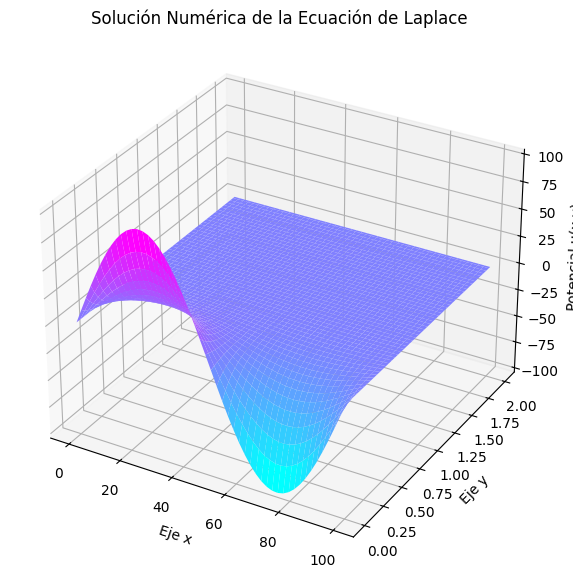

In [ ]:

L = 100
u0 = 100.0
Y_max = 2.0
max_iter = 1000
Nx = 50
Ny = 100
x = np.linspace(0, L, Nx)
y = np.linspace(0, Y_max, Ny)
X, Y = np.meshgrid(x, y)
V = np.zeros((Ny, Nx))
V
V[0, :] = u0 * np.sin(2 * np.pi * x / L)

for iteracion in range(max_iter):

    for j in range(1, Ny - 1):
        for i in range(1, Nx - 1):

            V[j, i] = 0.25 * (V[j+1, i] + V[j-1, i] + V[j, i+1] + V[j, i-1])


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, V, cmap='cool')

ax.set_title('Solución Numérica de la Ecuación de Laplace')
ax.set_xlabel('Eje x')
ax.set_ylabel('Eje y')
ax.set_zlabel('Potencial u(x,y)')



plt.show()

#Ejercicio 3

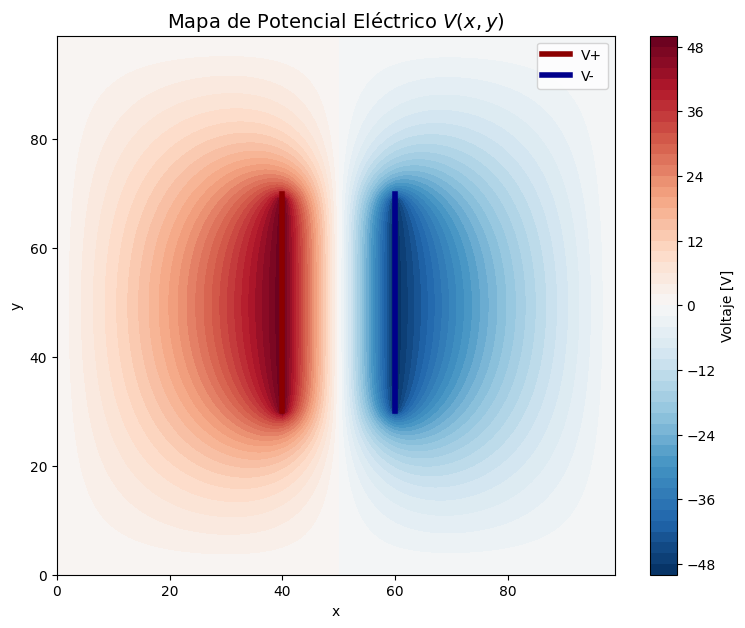

In [56]:
N = 100
V = np.zeros((N, N))
h = 1.0

# Posición de las placas (Paralelas al eje Y)
x1, x2 = 40, 60
y1, y2 = 30, 70
V[y1:y2, x1] = 50     # Placa positiva
V[y1:y2, x2] = -50    # Placa negativa

# Máscara de puntos fijos
fixed = np.zeros_like(V, dtype=bool)
fixed[y1:y2, x1] = True
fixed[y1:y2, x2] = True
fixed[0, :] = fixed[-1, :] = fixed[:, 0] = fixed[:, -1] = True

# Solución por Jacobi (Vectorizada)
for _ in range(3000):
    V_new = 0.25 * (np.roll(V, 1, axis=0) + np.roll(V, -1, axis=0) +
                    np.roll(V, 1, axis=1) + np.roll(V, -1, axis=1))
    V[~fixed] = V_new[~fixed]

X, Y = np.meshgrid(np.arange(N), np.arange(N))

plt.figure(figsize=(9, 7))

# Usamos RdBu_r para que el rojo sea positivo y azul negativo
im1 = plt.contourf(X, Y, V, levels=50, cmap='RdBu_r')

# Dibujar las placas físicamente
plt.plot([x1, x1], [y1, y2], color='darkred', lw=4, label='V+')
plt.plot([x2, x2], [y1, y2], color='darkblue', lw=4, label='V-')

plt.title('Mapa de Potencial Eléctrico $V(x,y)$', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(im1, label='Voltaje [V]')
plt.legend()

plt.show()


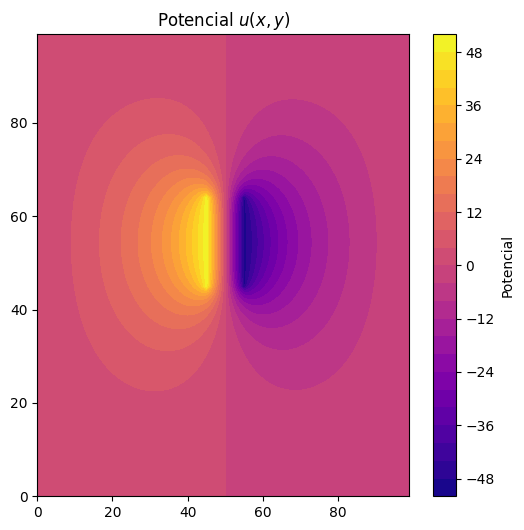

In [ ]:
plt.figure(figsize=(6,6))
plt.contourf(V, levels=30, cmap="plasma")  #Usamos la funcion contour que se recomendó en el enuncido del ejercicio
plt.colorbar(label="Potencial")
plt.title("Potencial $u(x,y)$")
plt.show()

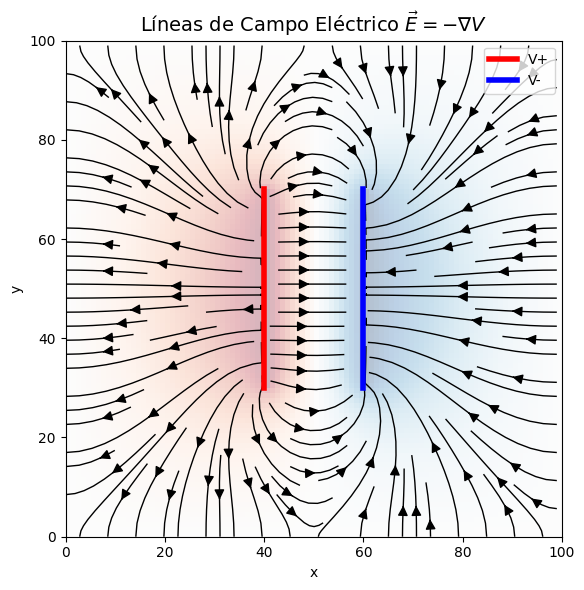

In [59]:
plt.figure(figsize=(10, 6))

plt.imshow(V, extent=[0, N, 0, N], origin='lower', cmap='RdBu_r', alpha=0.3)

plt.streamplot(X, Y, Ex, Ey, color='black', linewidth=1, density=1.2, arrowsize=1.5)

plt.plot([x1, x1], [y1, y2], color='red', lw=4, label='V+')
plt.plot([x2, x2], [y1, y2], color='blue', lw=4, label='V-')

plt.title('Líneas de Campo Eléctrico $\\vec{E} = -\\nabla V$', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, N)
plt.ylim(0, N)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()